# Emergency Routing Optimization 

## 1. libraries

In [ ]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import random
import time
import math

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("all libraries imported successfully")
print(f"random seed set to: {RANDOM_SEED}")

all libraries imported successfully
random seed set to: 42


## 2. Load Map Data & Extract Hospitals

In [3]:
place = "Ismailia, Egypt"
place_gdf = ox.geocode_to_gdf(place)
area = place_gdf.loc[0, "geometry"]

if area.geom_type == "Point":
    area = area.buffer(0.01)
area = area.buffer(0.01)

G = ox.graph_from_polygon(area, network_type="drive")
print(f"Area: {place}")
print(f"Nodes: {len(G.nodes)}")
print(f"Edges: {len(G.edges)}")

tags = {"amenity": ["hospital"]}
hospitals = ox.features_from_polygon(area, tags)
hospitals = hospitals[["geometry"]].dropna()
hospitals["geometry"] = hospitals["geometry"].centroid
hospitals["lat"] = hospitals.geometry.y
hospitals["lon"] = hospitals.geometry.x
hospitals = hospitals.head(10)

hospital_nodes = [
    ox.distance.nearest_nodes(G, row.lon, row.lat)
    for _, row in hospitals.iterrows()
]

print(f"Hospitals found: {len(hospital_nodes)}")
for i, node in enumerate(hospital_nodes):
    point = G.nodes[node]
    print(f"Hospital {i+1}: Node ID {node}, Coordinates: ({point['y']}, {point['x']})")

Area: Ismailia, Egypt
Nodes: 34978
Edges: 91197


C:\Users\Toqa Mohamed Fathy\AppData\Local\Temp\ipykernel_31344\4061362387.py:17: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  hospitals["geometry"] = hospitals["geometry"].centroid


Hospitals found: 5
Hospital 1: Node ID 7602494806, Coordinates: (30.5901131, 32.2626289)
Hospital 2: Node ID 11185555044, Coordinates: (30.6201296, 32.2862125)
Hospital 3: Node ID 7528711277, Coordinates: (30.5974311, 32.3087674)
Hospital 4: Node ID 1035334331, Coordinates: (30.62145, 32.2907251)
Hospital 5: Node ID 7223132320, Coordinates: (30.3209058, 32.3008526)


## 3. Generate Incidents & precomputaion 

In [4]:
NUM_EMERGENCIES = 10
emergencies = random.sample(list(G.nodes), NUM_EMERGENCIES)
print(f"Generated {NUM_EMERGENCIES} emergency incidents")
print(f"First 10 node IDs: {emergencies[:10]}")

all_nodes = list(set(emergencies + hospital_nodes))
t0 = time.time()
shortest_paths = {}
for n in all_nodes:
    shortest_paths[n] = nx.single_source_dijkstra_path_length(G, n, weight="length")
print(f"Precomputation done in {time.time() - t0:.4f}s")

def dist(a, b):
    return shortest_paths[a].get(b, float('inf'))

Generated 10 emergency incidents
First 10 node IDs: [7047101066, 4137180831, 6646520506, 6261422092, 4674634307, 7227151629, 6870259849, 6643922674, 9107260763, 4137182499]
Precomputation done in 3.8626s


## 4. Assign Emergencies to Nearest Hospital

In [ ]:
def assign_to_nearest(emergencies, hospital_nodes):
    assignments = {h: [] for h in hospital_nodes}
    for e in emergencies:
        best = min(hospital_nodes, key=lambda h: dist(h, e))
        assignments[best].append(e)
    return assignments

def total_distance(start, points):
    cost = 0
    current_node = start
    for p in points:
        cost += dist(current_node, p)
        current_node = p
    return cost

routes = assign_to_nearest(emergencies, hospital_nodes)
total_dis = sum(total_distance(h, pts) for h, pts in routes.items())
print(f"Baseline total distance: {total_dis:.4f} m")
for i, (h, pts) in enumerate(routes.items()):
    print(f"  Hospital {i}: {len(pts)} emergencies, {total_distance(h, pts):.4f} m")

Baseline total distance: 138588.5562 m
  Hospital 0: 8 emergencies, 125189.5017 m
  Hospital 1: 1 emergencies, 686.1360 m
  Hospital 2: 0 emergencies, 0.0000 m
  Hospital 3: 0 emergencies, 0.0000 m
  Hospital 4: 1 emergencies, 12712.9186 m


## 5. 2-Opt Local Search

In [ ]:
def two_opt(route, start):
    if len(route) < 2:
        return route[:]

    best = route[:]
    best_cost = total_distance(start, best)
    improved = True

    while improved:
        improved = False
        for i in range(len(best) - 1):
            for j in range(i + 1, len(best)):
                new_route = best[:]
                new_route[i:j+1] = best[i:j+1][::-1]
                new_cost = total_distance(start, new_route)
                if new_cost < best_cost:
                    best = new_route
                    best_cost = new_cost
                    improved = True
    return best

t0 = time.time()
two_opt_routes = {h: two_opt(pts, h) for h, pts in routes.items()}
two_opt_time = time.time() - t0

two_opt_total = sum(total_distance(h, pts) for h, pts in two_opt_routes.items())
print(f"2-Opt done in {two_opt_time:.2f}s")
print(f"2-Opt total distance: {two_opt_total:.2f} m")

2-Opt done in 0.00s
2-Opt total distance: 76561.70 m


## 6. Simulated Annealing


In [ ]:
def solution_cost(solution):
    return sum(total_distance(h, pts) for h, pts in solution.items())

def random_neighbor(solution):
    new_solution = {h: pts[:] for h, pts in solution.items()}
    move_type = random.choice(["swap_between", "move_between", "two_opt"])
    hospitals = list(new_solution.keys())

    if move_type == "swap_between" and len(hospitals) > 1:
        h1, h2 = random.sample(hospitals, 2)
        if new_solution[h1] and new_solution[h2]:
            i = random.randrange(len(new_solution[h1]))
            j = random.randrange(len(new_solution[h2]))
            new_solution[h1][i], new_solution[h2][j] = new_solution[h2][j], new_solution[h1][i]

    elif move_type == "move_between" and len(hospitals) > 1:
        h1, h2 = random.sample(hospitals, 2)
        if new_solution[h1]:
            i = random.randrange(len(new_solution[h1]))
            node = new_solution[h1].pop(i)
            new_solution[h2].append(node)

    elif move_type == "two_opt":
        h = random.choice(hospitals)
        route = new_solution[h]
        if len(route) >= 2:
            i, j = sorted(random.sample(range(len(route)), 2))
            route[i:j+1] = reversed(route[i:j+1])
            new_solution[h] = route

    return new_solution

def simulated_annealing_full(initial_solution,
                            T_init=6000.0,
                            cooling=0.995,
                            iterations=4000):
    current = {h: pts[:] for h, pts in initial_solution.items()}
    current_cost = solution_cost(current)
    best = {h: pts[:] for h, pts in current.items()}
    best_cost = current_cost
    T = T_init

    for it in range(iterations):
        neighbor = random_neighbor(current)
        neighbor_cost = solution_cost(neighbor)
        delta = neighbor_cost - current_cost

        if delta < 0 or random.random() < math.exp(-delta / T):
            current = neighbor
            current_cost = neighbor_cost
            if current_cost < best_cost:
                best = {h: pts[:] for h, pts in current.items()}
                best_cost = current_cost

        T *= cooling

        if it % 200 == 0:
            print(f"Iter {it}: Current = {current_cost:.2f}, Best = {best_cost:.2f}")

    return best

t0 = time.time()
sa_full_routes = simulated_annealing_full(routes)
sa_full_time = time.time() - t0
sa_full_total = solution_cost(sa_full_routes)

print(f"\nSA done in {sa_full_time:.3f}s")
print(f"SA total distance: {sa_full_total:.2f} m")
for i, (h, pts) in enumerate(sa_full_routes.items()):
    print(f"Hospital {i}: {len(pts)} emergencies, {total_distance(h, pts):.2f} m")

Iter 0: Current = 122607.53, Best = 122607.53
Iter 200: Current = 105349.84, Best = 93712.48
Iter 400: Current = 71988.56, Best = 71731.25
Iter 600: Current = 71459.14, Best = 71279.69
Iter 800: Current = 71459.14, Best = 71279.69
Iter 1000: Current = 69451.53, Best = 69451.53
Iter 1200: Current = 69451.53, Best = 69451.53
Iter 1400: Current = 69451.53, Best = 69451.53
Iter 1600: Current = 69451.53, Best = 69451.53
Iter 1800: Current = 69451.53, Best = 69451.53
Iter 2000: Current = 69451.53, Best = 69451.53
Iter 2200: Current = 69451.53, Best = 69451.53
Iter 2400: Current = 69451.53, Best = 69451.53
Iter 2600: Current = 69451.53, Best = 69451.53
Iter 2800: Current = 69451.53, Best = 69451.53
Iter 3000: Current = 69451.53, Best = 69451.53
Iter 3200: Current = 69451.53, Best = 69451.53
Iter 3400: Current = 69451.53, Best = 69451.53
Iter 3600: Current = 69451.53, Best = 69451.53
Iter 3800: Current = 69451.53, Best = 69451.53

SA done in 0.078s
SA total distance: 69451.53 m
Hospital 0: 4 e

## 7. Results Summary

In [ ]:
def improvement_pct(before, after):
    if before == 0:
        return 0.0
    return (before - after) / before * 100

print("=" * 55)
print(f"{'Method':<25} {'Total dist (m)':>14} {'Improvement':>12}")
print("-" * 55)
print(f"{'Baseline':<25} {total_dis:>14.1f} {'—':>12}")
print(f"{'2-Opt':<25} {two_opt_total:>14.1f} {improvement_pct(total_dis, two_opt_total):>11.2f}%")
print(f"{'Simulated Annealing':<25} {sa_full_total:>14.1f} {improvement_pct(total_dis, sa_full_total):>11.2f}%")
print("=" * 55)
print(f"\nTime: 2-Opt: {two_opt_time:.3f}s | SA: {sa_full_time:.3f}s")

Method                    Total dist (m)  Improvement
-------------------------------------------------------
Baseline                        138588.6            —
2-Opt                            76561.7       44.76%
Simulated Annealing              69451.5       49.89%

Time: 2-Opt: 0.001s | SA: 0.078s


## 8. Per-Hospital Comparison Bar Chart

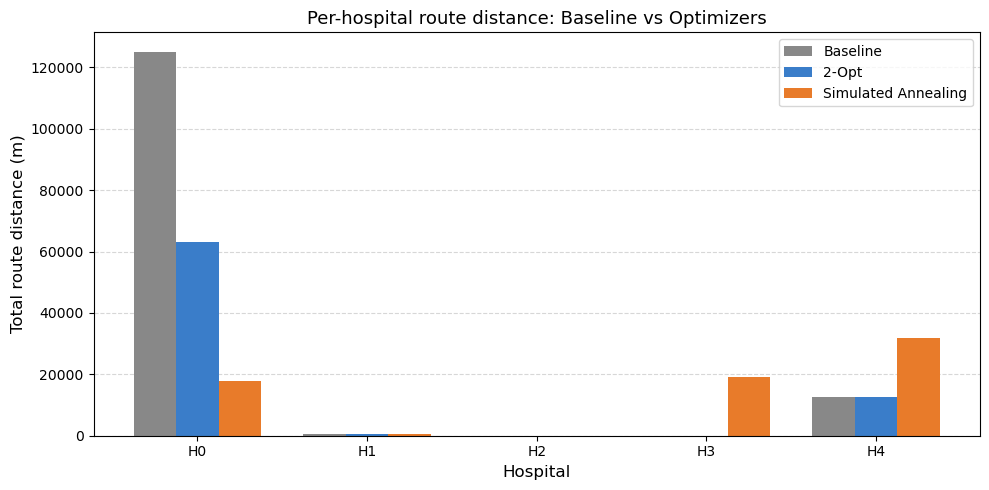

In [ ]:
hospital_labels = [f"H{i}" for i in range(len(routes))]
baseline_vals   = [total_distance(h, pts) for h, pts in routes.items()]
two_opt_vals    = [total_distance(h, pts) for h, pts in two_opt_routes.items()]
sa_vals         = [total_distance(h, sa_full_routes.get(h, [])) for h in routes.keys()]

x = np.arange(len(hospital_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, baseline_vals, width, label="Baseline",            color="#888888")
ax.bar(x,         two_opt_vals,  width, label="2-Opt",               color="#3A7DC9")
ax.bar(x + width, sa_vals,       width, label="Simulated Annealing", color="#E87B2A")

ax.set_xlabel("Hospital", fontsize=12)
ax.set_ylabel("Total route distance (m)", fontsize=12)
ax.set_title("Per-hospital route distance: Baseline vs Optimizers", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(hospital_labels)
ax.legend()
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 9. Visualization Baseline Routes

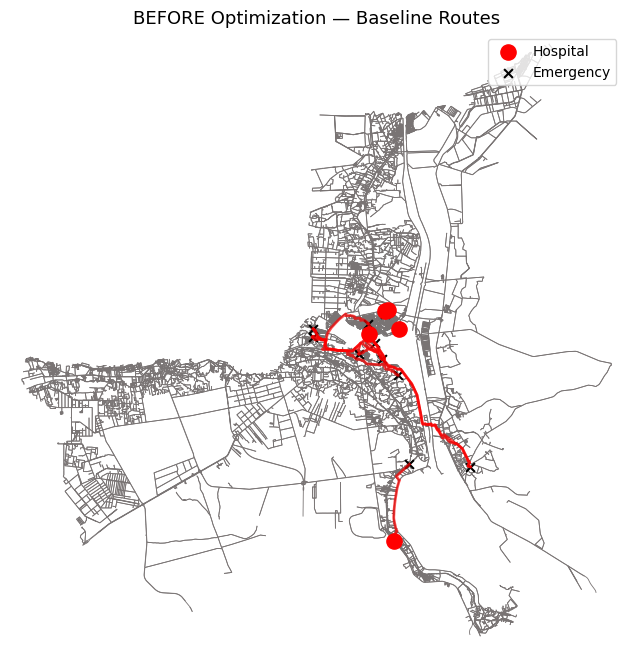

In [ ]:
fig, ax = ox.plot_graph(G, show=False, close=False, node_size=0,
                        edge_color="#797474", edge_linewidth=0.6, bgcolor="white")

for idx, (h, pts) in enumerate(routes.items()):
    cur = h
    ax.scatter(G.nodes[h]['x'], G.nodes[h]['y'], c="red", s=120,
            label="Hospital" if idx == 0 else "_nolegend_", zorder=5)
    for p in pts:
        try:
            route_path = nx.shortest_path(G, cur, p, weight="length")
            x_coords = [G.nodes[n]['x'] for n in route_path]
            y_coords = [G.nodes[n]['y'] for n in route_path]
            ax.plot(x_coords, y_coords, color="red", linewidth=2, alpha=0.7)
        except nx.NetworkXNoPath:
            print(f"[Warning] No path from {cur} to {p} — skipping.")
        ax.scatter(G.nodes[p]['x'], G.nodes[p]['y'], c="black", s=40, marker="x",
                label="Emergency" if (idx == 0 and p == pts[0]) else "_nolegend_")
        cur = p

ax.legend(loc="upper right")
plt.title("BEFORE Optimization — Baseline Routes", fontsize=13)
plt.show()

## 10. Visualization 2-Opt Optimized Routes

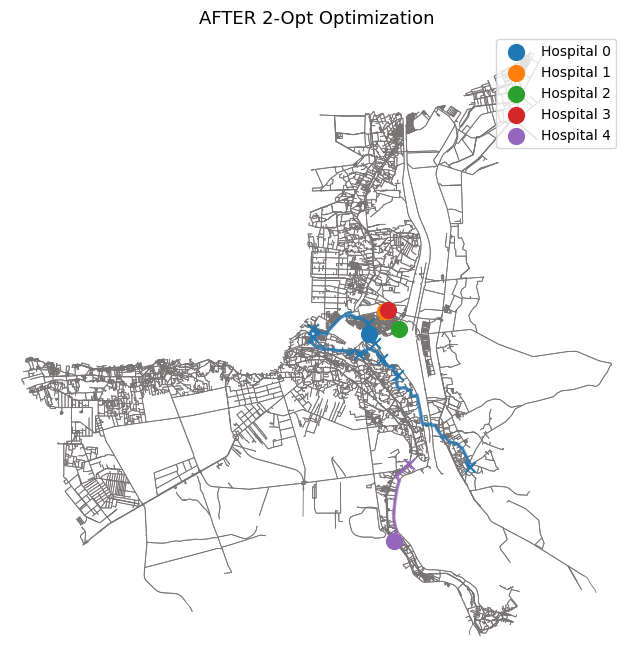

In [11]:
fig, ax = ox.plot_graph(G, show=False, close=False, node_size=0,
                        edge_color="#797474", edge_linewidth=0.6, bgcolor="white")
colors = plt.colormaps["tab10"]

for idx, (h, pts) in enumerate(two_opt_routes.items()):
    color = colors(idx)
    cur = h
    ax.scatter(G.nodes[h]['x'], G.nodes[h]['y'], c=[color], s=130,
            label=f"Hospital {idx}", zorder=5)
    for p in pts:
        try:
            route_path = nx.shortest_path(G, cur, p, weight="length")
            x_coords = [G.nodes[n]['x'] for n in route_path]
            y_coords = [G.nodes[n]['y'] for n in route_path]
            ax.plot(x_coords, y_coords, color=color, linewidth=2.5, alpha=0.75)
        except nx.NetworkXNoPath:
            print(f"[Warning] No path from {cur} to {p} — skipping.")
        ax.scatter(G.nodes[p]['x'], G.nodes[p]['y'], c=[color], s=60, marker="x")
        cur = p

ax.legend(loc="upper right")
plt.title("AFTER 2-Opt Optimization", fontsize=13)
plt.show()


## 11. Visualization Simulated Annealing Routes

c:\Users\Toqa Mohamed Fathy\anaconda35\Lib\site-packages\osmnx\plot.py:352: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(od_x, od_y, s=orig_dest_size, c=route_color, alpha=route_alpha, edgecolor="none")


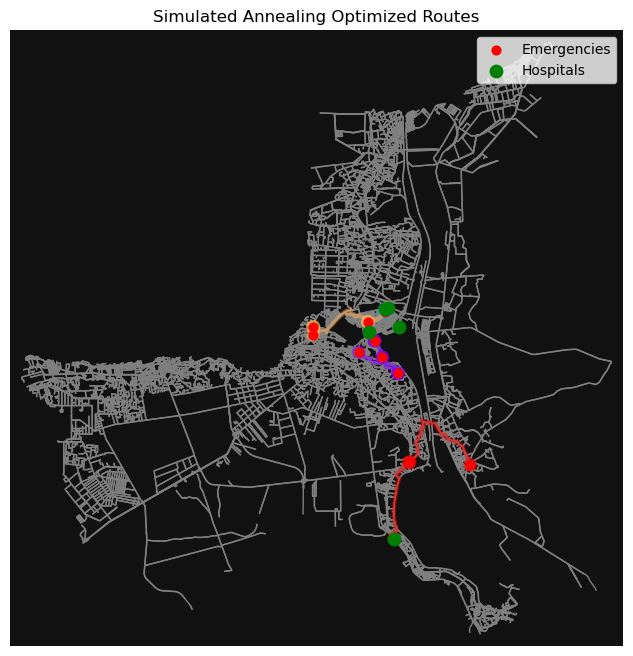

In [12]:
fig, ax = ox.plot_graph(G, show=False, close=False, node_size=0, edge_color='gray')

ex = [G.nodes[n]['x'] for n in emergencies]
ey = [G.nodes[n]['y'] for n in emergencies]
ax.scatter(ex, ey, c='red', s=40, label='Emergencies', zorder=3)

hx = [G.nodes[h]['x'] for h in hospital_nodes]
hy = [G.nodes[h]['y'] for h in hospital_nodes]
ax.scatter(hx, hy, c='green', s=80, label='Hospitals', zorder=4)

colors = cm.rainbow(np.linspace(0, 1, len(sa_full_routes)))

for (h, pts), color in zip(sa_full_routes.items(), colors):
    route = [h] + pts
    for i in range(len(route) - 1):
        try:
            path = nx.shortest_path(G, route[i], route[i+1], weight='length')
            ox.plot_graph_route(G, path, route_linewidth=3, route_color=color,
                                ax=ax, show=False, close=False)
        except:
            continue

ax.legend()
plt.title("Simulated Annealing Optimized Routes")
plt.show()

## 12. Cooling Schedule Sensitivity Analysis (SA)

Iter 0: Current = 142430.86, Best = 138588.56
Iter 200: Current = 71819.22, Best = 71819.22
Iter 400: Current = 69727.01, Best = 69727.01
Iter 600: Current = 69727.01, Best = 69727.01
Iter 800: Current = 69727.01, Best = 69727.01
Iter 1000: Current = 69727.01, Best = 69727.01
Iter 1200: Current = 69727.01, Best = 69727.01
Iter 1400: Current = 69727.01, Best = 69727.01
Iter 1600: Current = 69727.01, Best = 69727.01
Iter 1800: Current = 69727.01, Best = 69727.01
Iter 2000: Current = 69727.01, Best = 69727.01
Iter 2200: Current = 69727.01, Best = 69727.01
Iter 2400: Current = 69727.01, Best = 69727.01
Iter 2600: Current = 69727.01, Best = 69727.01
Iter 2800: Current = 69727.01, Best = 69727.01
Cooling=0.980 → 69727.0 m (0.06s)
Iter 0: Current = 138588.56, Best = 138588.56
Iter 200: Current = 93556.07, Best = 90802.32
Iter 400: Current = 71658.44, Best = 71658.44
Iter 600: Current = 71658.44, Best = 71658.44
Iter 800: Current = 71658.44, Best = 71658.44
Iter 1000: Current = 71658.44, Best 

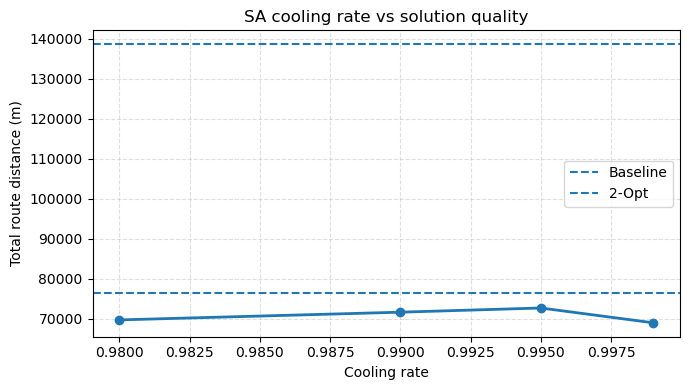

In [13]:
cooling_rates = [0.980, 0.990, 0.995, 0.999]
results = []
random.seed(RANDOM_SEED)

for cr in cooling_rates:
    t0 = time.time()
    routes_cr = simulated_annealing_full(routes, cooling=cr, iterations=3000)
    elapsed = time.time() - t0
    total = solution_cost(routes_cr)
    results.append((cr, total, elapsed))
    print(f"Cooling={cr:.3f} → {total:.1f} m ({elapsed:.2f}s)")

cr_vals   = [r[0] for r in results]
dist_vals = [r[1] for r in results]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cr_vals, dist_vals, marker="o", linewidth=2)
ax.set_xlabel("Cooling rate")
ax.set_ylabel("Total route distance (m)")
ax.set_title("SA cooling rate vs solution quality")
ax.axhline(total_dis,      linestyle="--", label="Baseline")
ax.axhline(two_opt_total,  linestyle="--", label="2-Opt")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()